<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving bank+marketing.zip to bank+marketing.zip


In [5]:
import zipfile

with zipfile.ZipFile("bank.zip", "r") as zip_ref:
    zip_ref.extractall("bank_data")

print("Files extracted successfully.")

Files extracted successfully.


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank_data/bank.csv", sep=";")

# Display first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [7]:
print(df.shape)
print(df.info())
print(df.describe(include="all"))

(4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None
                age         job  marital  education default       balance  \
count 

In [8]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("y", axis=1)
y = df["y"]

print(X.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   30   10        1          0        0     1787        0     0        0   
1   33    7        1          1        0     4789        1     1        0   
2   35    4        2          2        0     1350        1     0        0   
3   30    4        1          2        0     1476        1     1        2   
4   59    1        1          1        0        0        1     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  
0   19     10        79         1     -1         0         3  
1   11      8       220         1    339         4         0  
2   16      0       185         1    330         1         0  
3    3      6       199         4     -1         0         3  
4    5      8       226         1     -1         0         3  


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (3616, 16)
Testing Shape: (905, 16)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8718232044198895

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       807
           1       0.42      0.47      0.44        98

    accuracy                           0.87       905
   macro avg       0.68      0.70      0.68       905
weighted avg       0.88      0.87      0.88       905



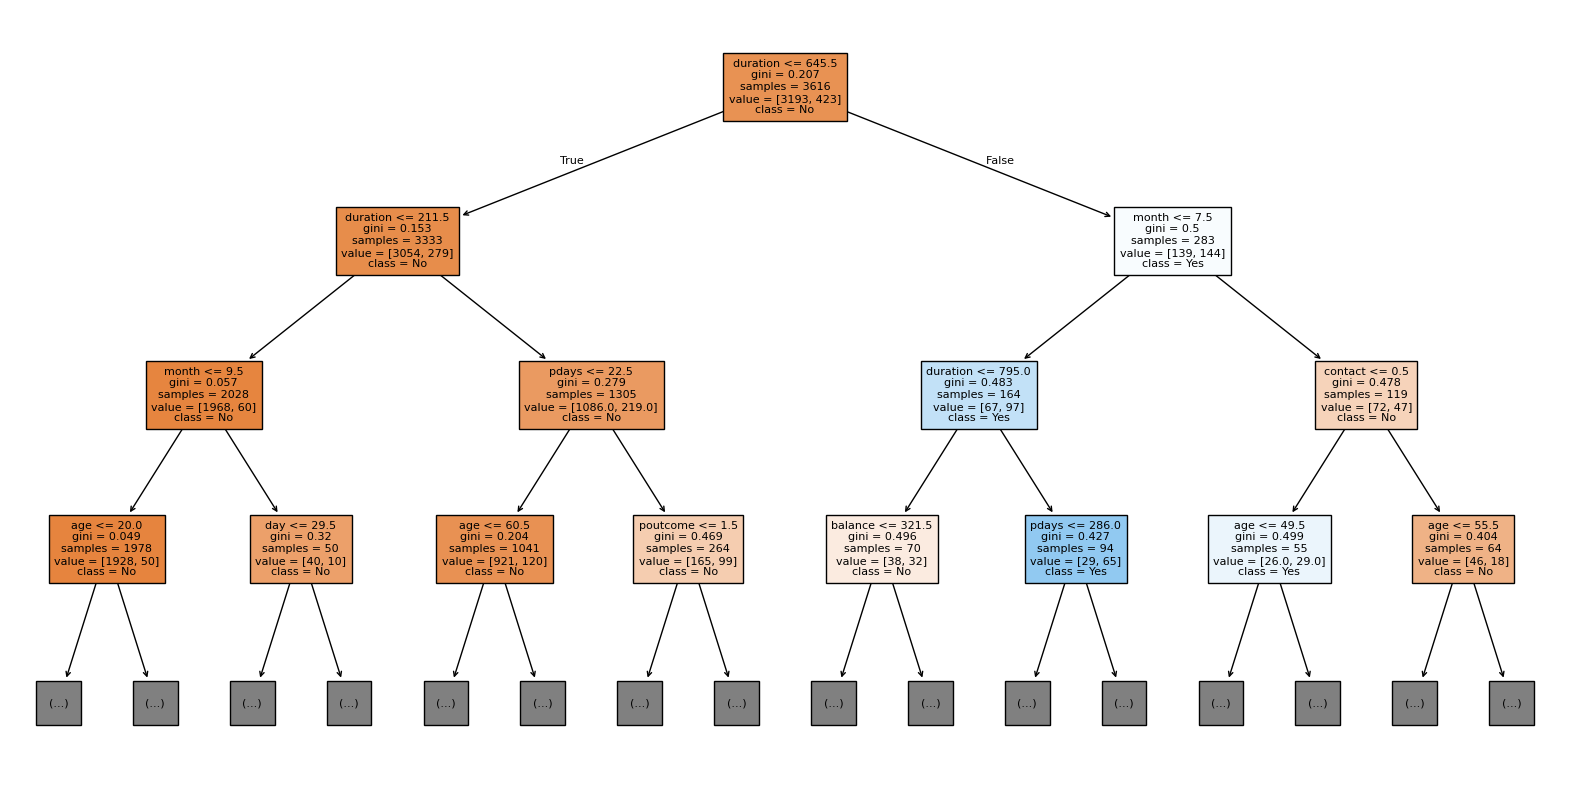

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

      Feature  Importance
11   duration    0.258636
9         day    0.146790
5     balance    0.135673
0         age    0.099244
13      pdays    0.082172
10      month    0.064929
1         job    0.057127
15   poutcome    0.056011
12   campaign    0.026560
2     marital    0.020737
8     contact    0.018402
6     housing    0.011922
3   education    0.008983
14   previous    0.006695
7        loan    0.003435
4     default    0.002683


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("K-NN Accuracy:", accuracy_score(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

K-NN Accuracy: 0.8906077348066298

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.49      0.18      0.27        98

    accuracy                           0.89       905
   macro avg       0.70      0.58      0.60       905
weighted avg       0.86      0.89      0.87       905



In [15]:
#Compare Algorithms
print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))
print("K-NN Accuracy          :", accuracy_score(y_test, knn_pred))

Decision Tree Accuracy : 0.8718232044198895
K-NN Accuracy          : 0.8906077348066298
